t-SNE in Python

In [10]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [3]:
digits = load_digits()
X, y = digits.data, digits.target

print(X.shape)
print(y.shape)

(1797, 64)
(1797,)


In [6]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [7]:
pca_2 = PCA(n_components=2, random_state=0)
X_pca = pca_2.fit_transform(X_std)

In [9]:
# riduzione del dataset a 30 feature prima di applicare t-SNE
pca_30 = PCA(n_components=30, random_state=0)
X_30 = pca_30.fit_transform(X_std) 

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42, verbose=1)
X_tsne = tsne.fit_transform(X_30)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1797 samples in 0.001s...
[t-SNE] Computed neighbors for 1797 samples in 0.709s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1797
[t-SNE] Computed conditional probabilities for sample 1797 / 1797
[t-SNE] Mean sigma: 2.130326
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.682846
[t-SNE] KL divergence after 1000 iterations: 0.819708


In [11]:
# applicazione di Kmeans sui dati ridotti con PCA e t-SNE

kmeans_pca = KMeans(n_clusters=10, random_state=42).fit(X_pca)
labels_pca = kmeans_pca.labels_

kmeans_tsne = KMeans(n_clusters=10, random_state=42).fit(X_tsne)
labels_tsne = kmeans_tsne.labels_

Plotting:
1. Dataset con PCA (p=2) con le vere etichette
2. Dataset con t-SNE (p=30) con le vere etichette
3. Clustering con Kmeans sul dataset ridotto con PCA
4. Clustering con Kmeans sul dataset ridotto con t-SNE

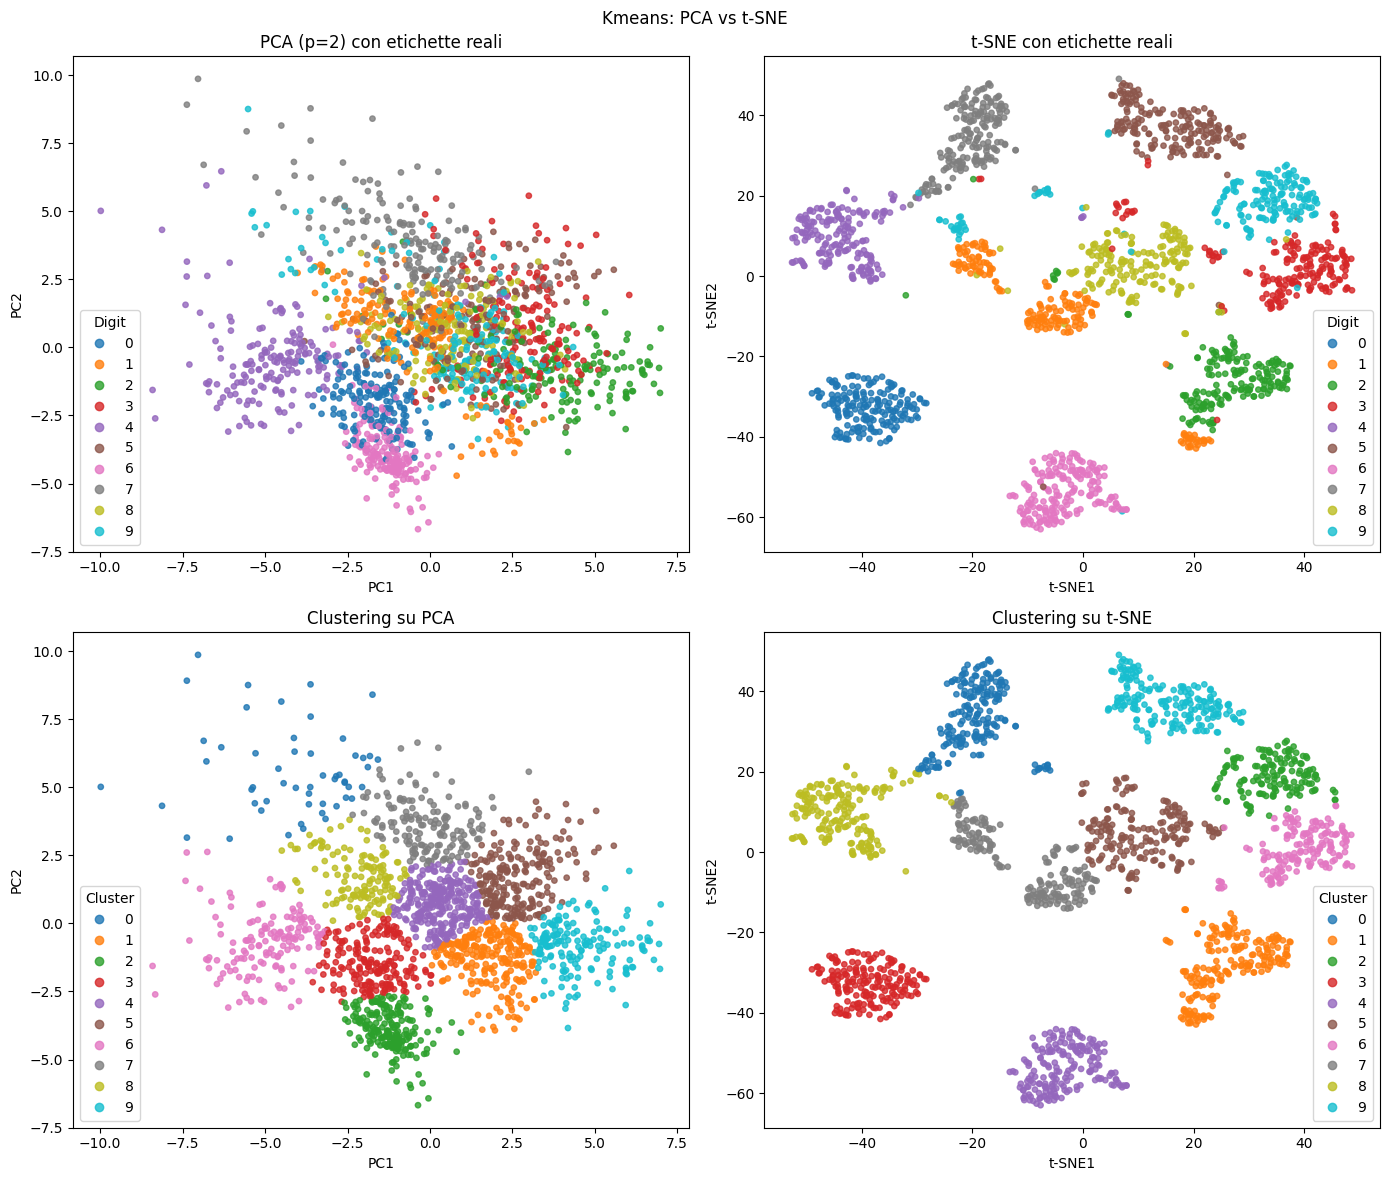

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Kmeans: PCA vs t-SNE")

# plot 1
ax = axes[0, 0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="tab10", s=15, alpha=0.8)
ax.set_title("PCA (p=2) con etichette reali")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(*scatter.legend_elements(), title="Digit", loc="best")

# plot 2
az = axes[0, 1]
scatter = az.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", s=15, alpha=0.8)
az.set_title("t-SNE con etichette reali")
az.set_xlabel("t-SNE1")
az.set_ylabel("t-SNE2")
az.legend(*scatter.legend_elements(), title="Digit", loc="best")

# plot 3
ax = axes[1, 0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap="tab10", s=15, alpha=0.8)
ax.set_title("Clustering su PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(*scatter.legend_elements(), title="Cluster", loc="best")

#plot 4
ax = axes[1, 1]
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_tsne, cmap="tab10", s=15, alpha=0.8)
ax.set_title("Clustering su t-SNE")
ax.set_xlabel("t-SNE1")
ax.set_ylabel("t-SNE2")
ax.legend(*scatter.legend_elements(), title="Cluster", loc="best")

plt.tight_layout()
plt.show()
